In [1]:
import re 
import pandas as pd 
import matplotlib.pyplot as plt 

plt.style.use("seaborn-v0_8")

In [2]:
with open("auth.log", "r") as f:
    log_data = f.read()
log_data[:500]


'Jan 10 08:12:33 server sshd[1234]: Failed password for invalid user admin from 192.168.1.22 port 51232 ssh2\nJan 10 08:12:35 server sshd[1234]: Failed password for root from 185.23.44.101 port 60123 ssh2\nJan 10 08:12:36 server sshd[1234]: Failed password for root from 185.23.44.101 port 60123 ssh2\nJan 10 08:12:38 server sshd[1234]: Failed password for user from 23.71.90.4 port 44102 ssh2\nJan 10 08:12:41 server sshd[1234]: Failed password for root from 185.23.44.101 port 60123 ssh2\nJan 10 08:12:45'

In [3]:
pattern = r"Failed password for .* from (\d+\.\d+\.\d+\.\d+) port" 
ips = re.findall(pattern, log_data)

print(f"Total Failed Login attempts found: {len(ips)}")
ips[:10]

Total Failed Login attempts found: 6


['192.168.1.22',
 '185.23.44.101',
 '185.23.44.101',
 '23.71.90.4',
 '185.23.44.101',
 '23.71.90.4']

In [4]:
df = pd.DataFrame(ips, columns=["ip"])
df["count"] = 1

df_grouped = df.groupby("ip").sum().sort_values("count", ascending=False)
df_grouped



,count
ip,
185.23.44.101,3
23.71.90.4,2
192.168.1.22,1


<Figure size 1000x500 with 0 Axes>

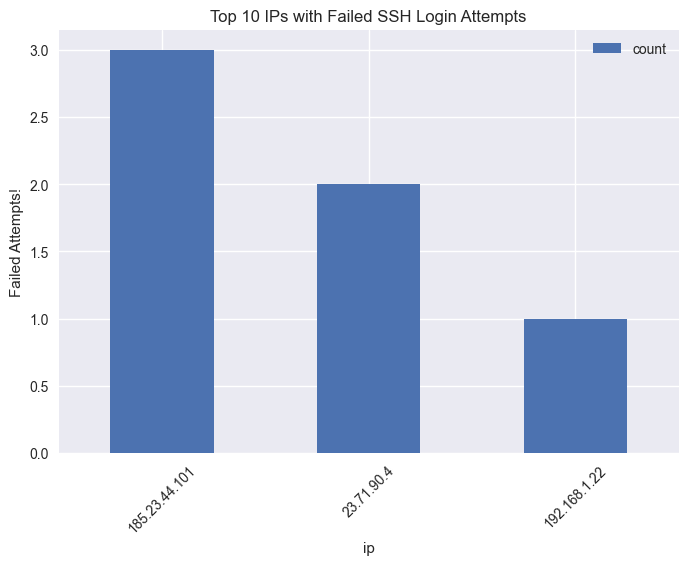

In [5]:
plt.figure(figsize=(10,5))
df_grouped.head(10).plot(kind="bar")
plt.title("Top 10 IPs with Failed SSH Login Attempts")
plt.ylabel("Failed Attempts!")
plt.xticks(rotation=45)
plt.show()

In [6]:
THRESHOLD = 5

suspicious_ips = df_grouped[df_grouped["count"] >= THRESHOLD]
suspicious_ips


,count
ip,


In [7]:
timestamp_pattern = (
    r"([A-Z][a-z]{2}\s+\d{1,2}\s+\d\d:\d\d:\d\d).*Failed password.*from (\d+\.\d+\.\d+\.\d+)"
)

matches = re.findall(timestamp_pattern, log_data)

time_df = pd.DataFrame(matches, columns=["timestamp", "ip"])
time_df.head()


,timestamp,ip
0,Jan 10 08:12:33,192.168.1.22
1,Jan 10 08:12:35,185.23.44.101
2,Jan 10 08:12:36,185.23.44.101
3,Jan 10 08:12:38,23.71.90.4
4,Jan 10 08:12:41,185.23.44.101


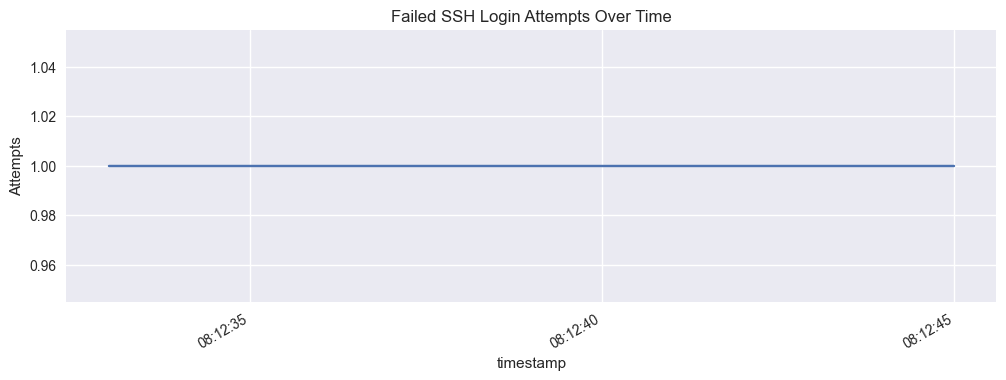

In [8]:
time_df["timestamp"] = pd.to_datetime(
    time_df["timestamp"], format="%b %d %H:%M:%S", errors="coerce"
)

plt.figure(figsize=(12,4))
time_df.groupby("timestamp").count()["ip"].plot()
plt.title("Failed SSH Login Attempts Over Time")
plt.ylabel("Attempts")
plt.show()


In [9]:
# Summary
# Extracted failed SSH login attempts from `auth.log`
#Identified the most frequent attacking IPs
#Highlighted suspicious IPs with excessive attempts
#Visualized log activity with charts  


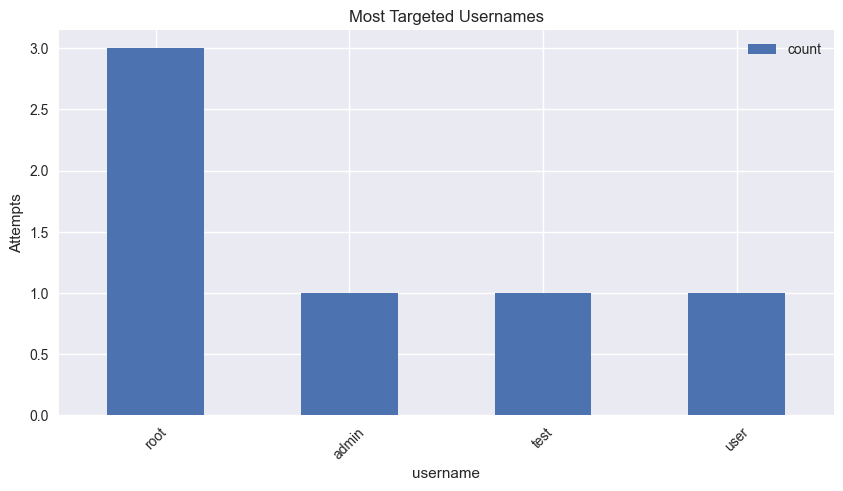

In [10]:
user_pattern = r"Failed password for (?:invalid user )?(\w+) from"
users = re.findall(user_pattern, log_data)

user_df = pd.DataFrame(users, columns=["username"])
user_df["count"] = 1

user_grouped = user_df.groupby("username").sum().sort_values("count", ascending=False)
user_grouped


user_grouped.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Most Targeted Usernames")
plt.ylabel("Attempts")
plt.xticks(rotation=45)
plt.show()


In [11]:
combo_pattern = r"Failed password for (?:invalid user )?(\w+) from  (\d+\.\d+\.\d+\.\d+)"
combo_matches = re.findall(combo_pattern, log_data)

combo_df = pd.DataFrame(combo_matches, columns=["username", "ip"])
combo_df["count"] = 1

combo_df.groupby(["ip", "username"]).sum().sort_values("count", ascending=False).head(15)


,,count
ip,username,


In [12]:
multi_attackers = (
    combo_df.groupby("ip")["username"]
    .nunique()
    .sort_values(ascending=False)
)
multi_attackers.head(10)


multi_suspicious = multi_attackers[multi_attackers >= 3]
multi_suspicious


Series([], Name: username, dtype: int64)

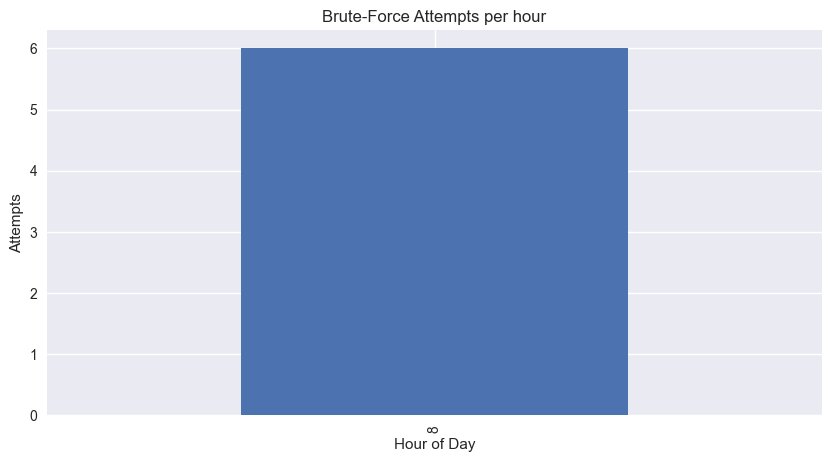

In [13]:
time_df['hour'] = time_df['timestamp'].dt.hour
hour_counts = time_df.groupby("hour").count()["ip"]
hour_counts.plot(kind="bar", figsize=(10,5))
plt.title("Brute-Force Attempts per hour")
plt.xlabel("Hour of Day")
plt.ylabel("Attempts")
plt.show()